## Hometask

1. Classify the signs (fingers) dataset

2. Try to change the number of hidden layer

3. Change the activation to tanh or sigmoid and see what happens

4. Change the dropout ratio and check the performance

Import Libraries

In [2]:
import numpy as np
import h5py
import matplotlib.pyplot as plt 
 
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense 

Load the Data

In [5]:
def load_dataset():
    fn = 'dataset/train_signs.h5'
    train_dataset = h5py.File(fn, "r")
    X_train = np.array(train_dataset["train_set_x"][:]) # your train set features
    Y_train = np.array(train_dataset["train_set_y"][:]) # your train set labels

    fn = 'dataset/test_signs.h5'
    test_dataset =  h5py.File(fn, "r")
    X_test = np.array(test_dataset["test_set_x"][:]) # your test set features
    Y_test = np.array(test_dataset["test_set_y"][:]) # your test set labels

    classes = np.array(test_dataset["list_classes"][:]) # the list of classes
    
    Y_train = Y_train.reshape((1, Y_train.shape[0]))
    Y_test = Y_test.reshape((1, Y_test.shape[0]))
    
    return X_train, Y_train, X_test, Y_test, classes
train_data, train_labels, test_data, test_labels, classes = load_dataset()

print ('train_data.shape=', train_data.shape)
print ('train_labels.shape=',  train_labels.shape)
print ('test_data.shape=', test_data.shape)
print ('test_labels.shape=', test_labels.shape)


train_data.shape= (1080, 64, 64, 3)
train_labels.shape= (1, 1080)
test_data.shape= (120, 64, 64, 3)
test_labels.shape= (1, 120)



Review the data

In [6]:
def display_samples_in_grid(X, n_rows, n_cols= None, y = None ):
    if n_cols is None:
        n_cols= n_rows
    indices = np.random.randint(0, len(X),n_rows*n_cols)
    for i in range (n_rows):
        for j in range (n_cols):
            index = n_cols*i+j
            ax = plt.subplot(n_rows,n_cols,index+1)
            ax.imshow(X[indices[index]], cmap='Greys')
            if not (y is None):
                plt.title(y[indices[index]])
            plt.axis('off')

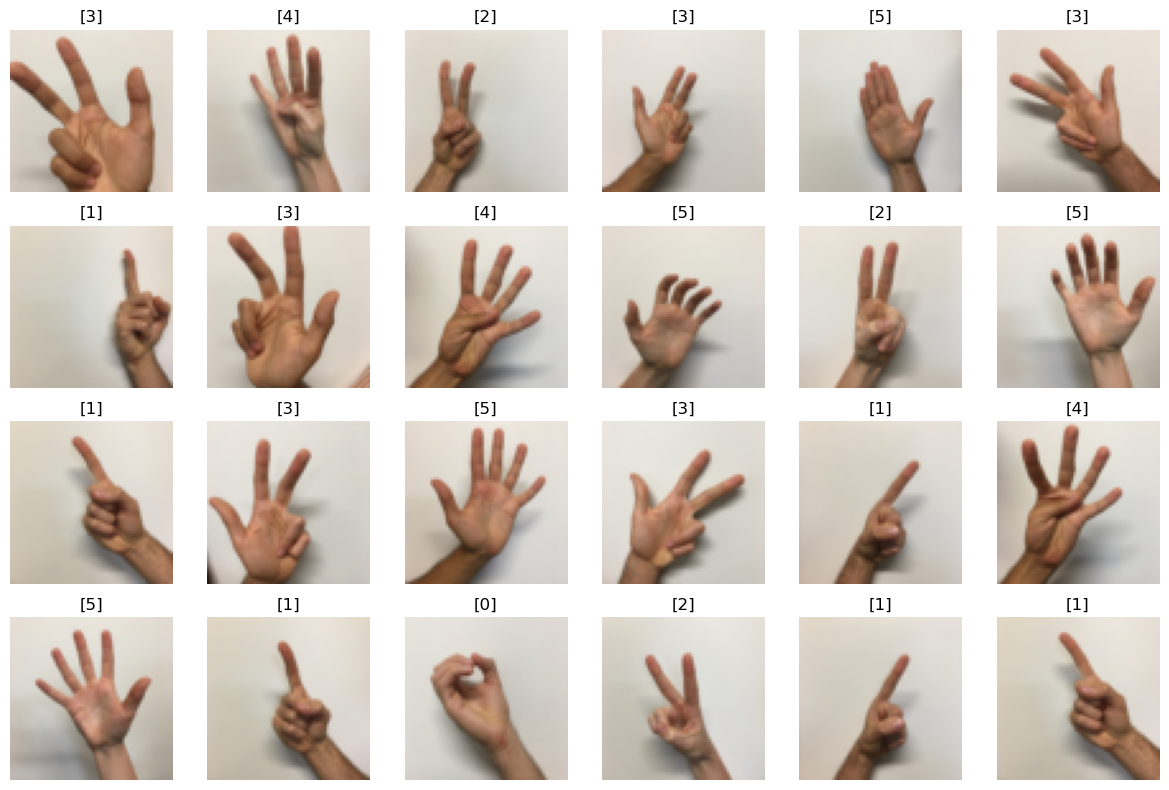

In [7]:
plt.figure(figsize= (12,8))
display_samples_in_grid(train_data, n_rows=4, n_cols=6, y= train_labels.T)
plt.tight_layout(h_pad=1, w_pad=1)

Preprocess the data

In [8]:
m_train, num_px,_,_ = train_data.shape
m_test = test_data.shape[0]

train_data_flatten = train_data.reshape(m_train, -1)
test_data_flatten = test_data.reshape(m_test, -1)

train_data_scaled = train_data_flatten / 255
test_data_scaled = test_data_flatten / 255


train_labels = np.squeeze(train_labels)
test_labels = np.squeeze(test_labels) 

Y_train_one_hot = to_categorical(train_labels)
Y_test_one_hot = to_categorical(test_labels)


Let's define a constant

In [9]:
nClasses = len(classes)
nRows,nCols,nDims = train_data.shape[1:]

batch_size = 256
epochs = 50

1. Classify the signs (fingers) dataset

In [ ]:
def get_model():
    model = Sequential([
    Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(nRows,nCols,nDims)), 
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    
    Conv2D(64, (3, 3), padding='same', activation='relu'), 
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Flatten(),
 
    Dense(64, activation='relu'), 
    Dense(nClasses, activation='softmax')
    ])
    return model

model = get_model()

f:\Anaconda3_Py_Env2\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Configure the model

In [303]:
model.compile(optimizer='rmsprop', loss='categorical_crossentropy', metrics=['accuracy'])


Train the model

In [304]:
history = model.fit(train_data, Y_train_one_hot, batch_size=batch_size, epochs=epochs, verbose=1, 
                   validation_data=(test_data, Y_test_one_hot))

Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 491ms/step - accuracy: 0.1685 - loss: 110.3146 - val_accuracy: 0.1750 - val_loss: 6.5412
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 392ms/step - accuracy: 0.1444 - loss: 6.0688 - val_accuracy: 0.1417 - val_loss: 2.1207
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 396ms/step - accuracy: 0.2231 - loss: 1.8180 - val_accuracy: 0.3500 - val_loss: 1.5949
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 390ms/step - accuracy: 0.3685 - loss: 1.7068 - val_accuracy: 0.3833 - val_loss: 1.7831
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 326ms/step - accuracy: 0.4583 - loss: 1.4187 - val_accuracy: 0.4000 - val_loss: 1.5772
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 292ms/step - accuracy: 0.6074 - loss: 1.1045 - val_accuracy: 0.5083 - val_loss: 1.3289
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 306ms/step - accuracy: 0.7269 - loss: 0.8443 - val_accuracy: 0.4250 - val_loss: 1.4541
Epoch 8/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 287ms/step - accuracy: 0.7481 - loss: 0.7599 - val_accuracy: 0.6250 - val_los

Evaluate the trained model

In [305]:

[test_loss, test_acc] = model.evaluate(test_data, Y_test_one_hot)
print("Evaluation result on Test Data : Loss = {}, accuracy = {}".format(test_loss, test_acc))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8583 - loss: 0.7013
Evaluation result on Test Data : Loss = 0.7013261318206787, accuracy = 0.8583333492279053


Check for Overfitting

Text(0.5, 1.0, 'Accuracy Curves')

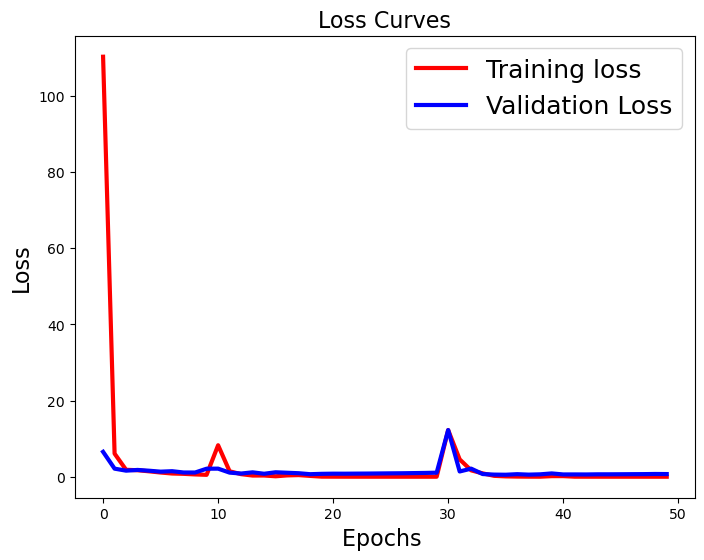

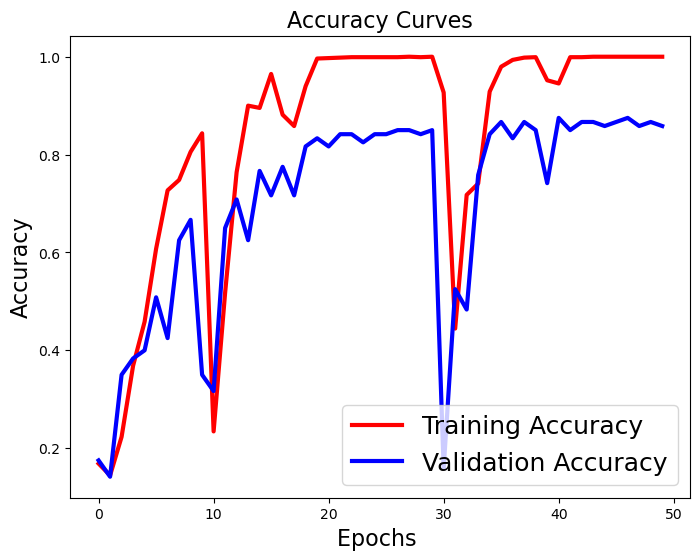

In [306]:
#Plot the Loss Curves
plt.figure(figsize=[8,6])
plt.plot(history.history['loss'],'r',linewidth=3.0)
plt.plot(history.history['val_loss'],'b',linewidth=3.0)
plt.legend(['Training loss', 'Validation Loss'],fontsize=18)
plt.xlabel('Epochs ',fontsize=16)
plt.ylabel('Loss',fontsize=16)
plt.title('Loss Curves',fontsize=16)
 
#Plot the Accuracy Curves
plt.figure(figsize=[8,6])
plt.plot(history.history['accuracy'],'r',linewidth=3.0)
plt.plot(history.history['val_accuracy'],'b',linewidth=3.0)
plt.legend(['Training Accuracy', 'Validation Accuracy'],fontsize=18)
plt.xlabel('Epochs ',fontsize=16)
plt.ylabel('Accuracy',fontsize=16)
plt.title('Accuracy Curves',fontsize=16)

2. Try to change the number of hidden layer

In [307]:
def get_model():
    model = Sequential([
    Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(nRows,nCols,nDims)), 
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Conv2D(32,(3,3), padding='same', activation='relu'), 
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Conv2D(64,(3,3), padding='same', activation='relu'), 
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Flatten(),
     
    Dense(64, activation='relu'),
    Dense(nClasses, activation='softmax')
    ])
    return model

model2 = get_model()

In [308]:
model2.compile(optimizer='rmsprop', loss='categorical_crossentropy', metrics=['accuracy'])

history = model2.fit(train_data, Y_train_one_hot, batch_size=batch_size, epochs=epochs, verbose=1, 
                   validation_data=(test_data, Y_test_one_hot))

Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 374ms/step - accuracy: 0.1722 - loss: 20.4878 - val_accuracy: 0.1667 - val_loss: 2.6743
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 358ms/step - accuracy: 0.1889 - loss: 2.1255 - val_accuracy: 0.1750 - val_loss: 1.8010
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 360ms/step - accuracy: 0.2120 - loss: 1.7516 - val_accuracy: 0.1833 - val_loss: 1.7352
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 369ms/step - accuracy: 0.3481 - loss: 1.6556 - val_accuracy: 0.2333 - val_loss: 1.7196
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 340ms/step - accuracy: 0.4157 - loss: 1.5188 - val_accuracy: 0.3667 - val_loss: 1.5056
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 314ms/step - accuracy: 0.4343 - loss: 1.4564 - val_accuracy: 0.4417 - val_loss: 1.4883
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 310ms/step - accuracy: 0.4722 - loss: 1.4172 - val_accuracy: 0.5167 - val_loss: 1.3328
Epoch 8/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 321ms/step - accuracy: 0.3102 - loss: 4.2931 - val_accuracy: 0.4417 - val_loss

In [309]:

[test_loss, test_acc] = model2.evaluate(test_data, Y_test_one_hot)
print("Evaluation result on Test Data : Loss = {}, accuracy = {}".format(test_loss, test_acc))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.9000 - loss: 0.7829
Evaluation result on Test Data : Loss = 0.7828595042228699, accuracy = 0.8999999761581421


Text(0.5, 1.0, 'Accuracy Curves')

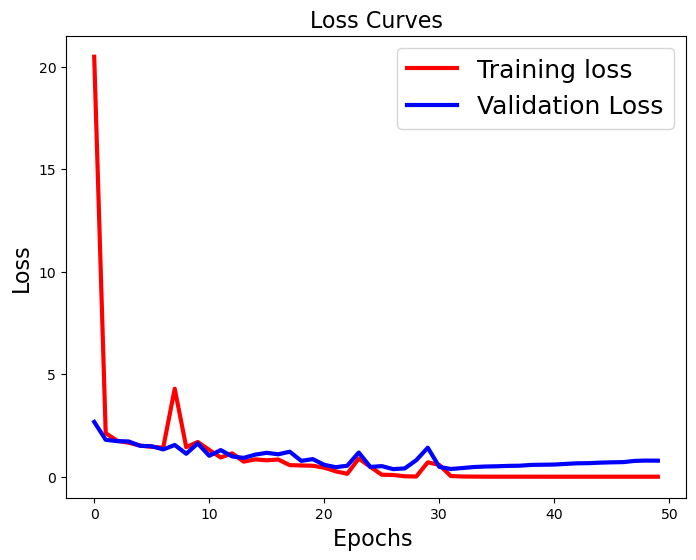

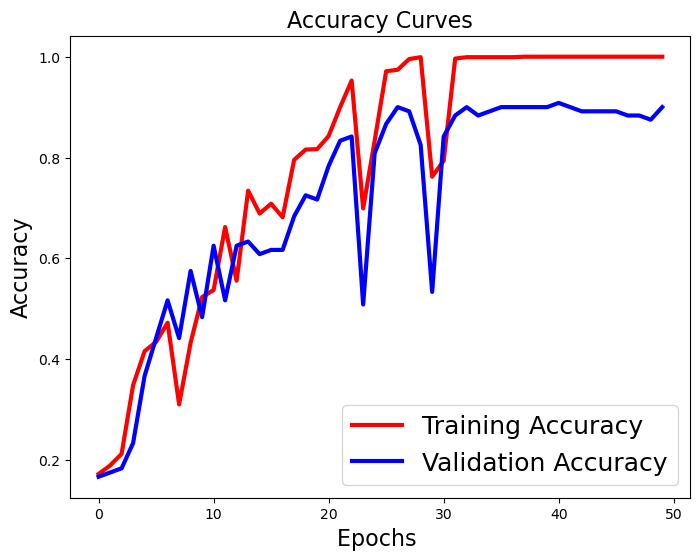

In [310]:
#Plot the Loss Curves
plt.figure(figsize=[8,6])
plt.plot(history.history['loss'],'r',linewidth=3.0)
plt.plot(history.history['val_loss'],'b',linewidth=3.0)
plt.legend(['Training loss', 'Validation Loss'],fontsize=18)
plt.xlabel('Epochs ',fontsize=16)
plt.ylabel('Loss',fontsize=16)
plt.title('Loss Curves',fontsize=16)
 
#Plot the Accuracy Curves
plt.figure(figsize=[8,6])
plt.plot(history.history['accuracy'],'r',linewidth=3.0)
plt.plot(history.history['val_accuracy'],'b',linewidth=3.0)
plt.legend(['Training Accuracy', 'Validation Accuracy'],fontsize=18)
plt.xlabel('Epochs ',fontsize=16)
plt.ylabel('Accuracy',fontsize=16)
plt.title('Accuracy Curves',fontsize=16)

3. Change the activation to tanh or sigmoid and see what happens

In [311]:
def get_model():
    model = Sequential([
    Conv2D(32, (3, 3), padding='same', activation='sigmoid', input_shape=(nRows,nCols,nDims)), 
    Conv2D(32, (3, 3), activation='sigmoid'),
    MaxPooling2D((2, 2)),

    Conv2D(32,(3,3), padding='same', activation='sigmoid'), 
    Conv2D(32, (3, 3), activation='sigmoid'),
    MaxPooling2D((2, 2)), 

    Conv2D(64,(3,3), padding='same', activation='sigmoid'), 
    Conv2D(64, (3, 3), activation='sigmoid'),
    MaxPooling2D((2, 2)), 
 
    Flatten(),
      
    Dense(64, activation='sigmoid'), 
    Dense(nClasses, activation='softmax')
    ])
    return model
model3 = get_model()

Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 439ms/step - accuracy: 0.1602 - loss: 2.2342 - val_accuracy: 0.1667 - val_loss: 1.8369
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 382ms/step - accuracy: 0.1565 - loss: 1.8110 - val_accuracy: 0.1667 - val_loss: 1.8130
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 392ms/step - accuracy: 0.1778 - loss: 1.8009 - val_accuracy: 0.1667 - val_loss: 1.8263
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 364ms/step - accuracy: 0.1787 - loss: 1.8048 - val_accuracy: 0.1667 - val_loss: 1.8545
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 378ms/step - accuracy: 0.1630 - loss: 1.8127 - val_accuracy: 0.1667 - val_loss: 1.8096
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 379ms/step - accuracy: 0.1546 - loss: 1.8110 - val_accuracy: 0.1667 - val_loss: 1.8101
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 380ms/step - accuracy: 0.1519 - loss: 1.8049 - val_accuracy: 0.1667 - val_loss: 1.8030
Epoch 8/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 397ms/step - accuracy: 0.1676 - loss: 1.7992 - val_accuracy: 0.1667 - val_loss:

Text(0.5, 1.0, 'Accuracy Curves')

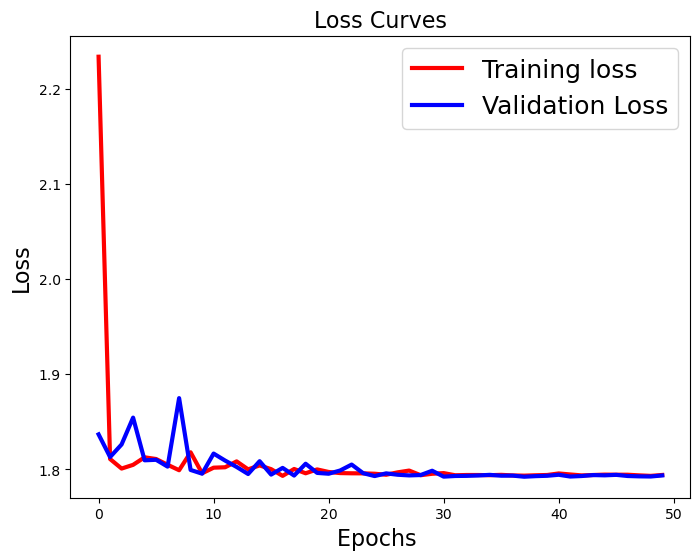

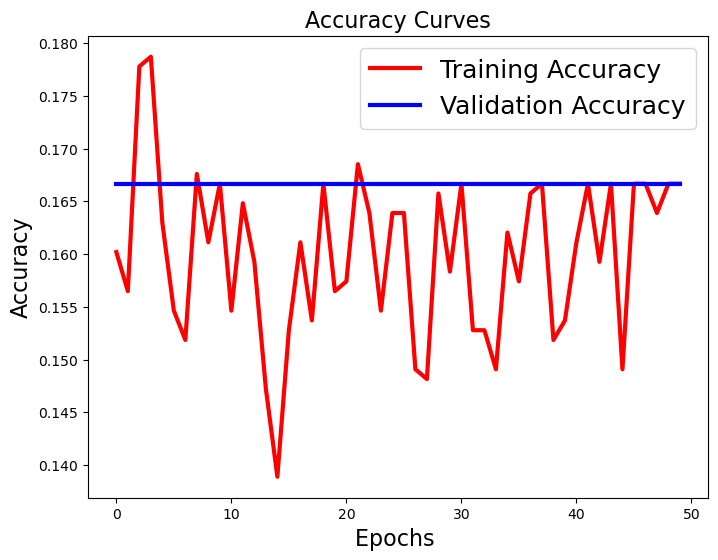

In [ ]:
model3.compile(optimizer='rmsprop', loss='categorical_crossentropy', metrics=['accuracy'])

history = model3.fit(train_data, Y_train_one_hot, batch_size=batch_size, epochs=epochs, verbose=1, 
                   validation_data=(test_data, Y_test_one_hot))

#Plot the Loss Curves
plt.figure(figsize=[8,6])
plt.plot(history.history['loss'],'r',linewidth=3.0)
plt.plot(history.history['val_loss'],'b',linewidth=3.0)
plt.legend(['Training loss', 'Validation Loss'],fontsize=18)
plt.xlabel('Epochs ',fontsize=16)
plt.ylabel('Loss',fontsize=16)
plt.title('Loss Curves',fontsize=16)
 
#Plot the Accuracy Curves
plt.figure(figsize=[8,6])
plt.plot(history.history['accuracy'],'r',linewidth=3.0)
plt.plot(history.history['val_accuracy'],'b',linewidth=3.0)
plt.legend(['Training Accuracy', 'Validation Accuracy'],fontsize=18)
plt.xlabel('Epochs ',fontsize=16)
plt.ylabel('Accuracy',fontsize=16)
plt.title('Accuracy Curves',fontsize=16)

In [313]:

[test_loss, test_acc] = model3.evaluate(test_data, Y_test_one_hot)
print("Evaluation result on Test Data : Loss = {}, accuracy = {}".format(test_loss, test_acc))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.1667 - loss: 1.7937
Evaluation result on Test Data : Loss = 1.7936753034591675, accuracy = 0.1666666716337204


4. Change the dropout ratio and check the performance

In [314]:
def get_model():
    model = Sequential([
    Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(nRows,nCols,nDims)),
    Conv2D(32, (3, 3), activation='relu'),
    Dropout(0.2),
    MaxPooling2D((2, 2)),

    Conv2D(32,(3,3), padding='same', activation='relu'),
    Conv2D(32, (3, 3), activation='relu'),
    Dropout(0.2),
    MaxPooling2D((2, 2)),

    Conv2D(64,(3,3), padding='same', activation='relu'),
    Conv2D(64,(3,3), activation='relu'),
    Dropout(0.2),
    MaxPooling2D((2, 2)),

    Flatten(),
      
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(nClasses, activation='softmax')
    ])
    return model
model4 = get_model()

Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 435ms/step - accuracy: 0.1620 - loss: 40.3264 - val_accuracy: 0.1500 - val_loss: 2.4776
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 387ms/step - accuracy: 0.1944 - loss: 2.4298 - val_accuracy: 0.2167 - val_loss: 1.7556
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 385ms/step - accuracy: 0.2463 - loss: 1.7813 - val_accuracy: 0.2000 - val_loss: 1.7256
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 388ms/step - accuracy: 0.2806 - loss: 1.6798 - val_accuracy: 0.2250 - val_loss: 1.8161
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 396ms/step - accuracy: 0.2491 - loss: 1.8165 - val_accuracy: 0.4333 - val_loss: 1.6556
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 389ms/step - accuracy: 0.3704 - loss: 1.5432 - val_accuracy: 0.3917 - val_loss: 1.5587
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 386ms/step - accuracy: 0.3046 - loss: 1.6975 - val_accuracy: 0.3583 - val_loss: 1.5408
Epoch 8/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 396ms/step - accuracy: 0.3806 - loss: 1.5509 - val_accuracy: 0.4333 - val_loss

Text(0.5, 1.0, 'Accuracy Curves')

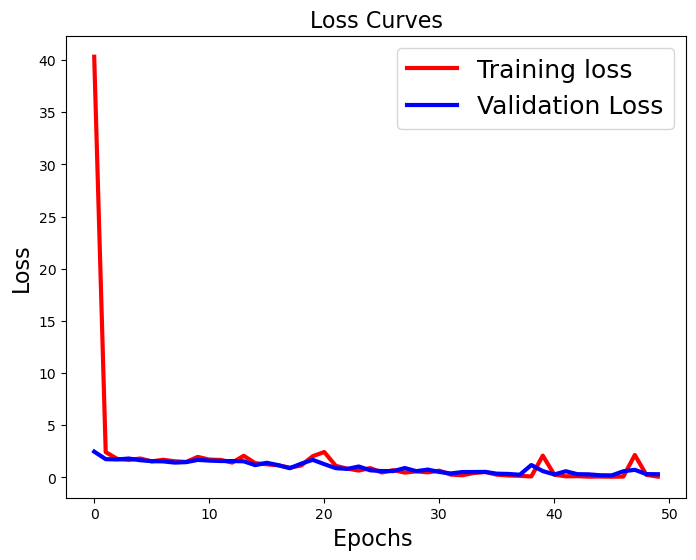

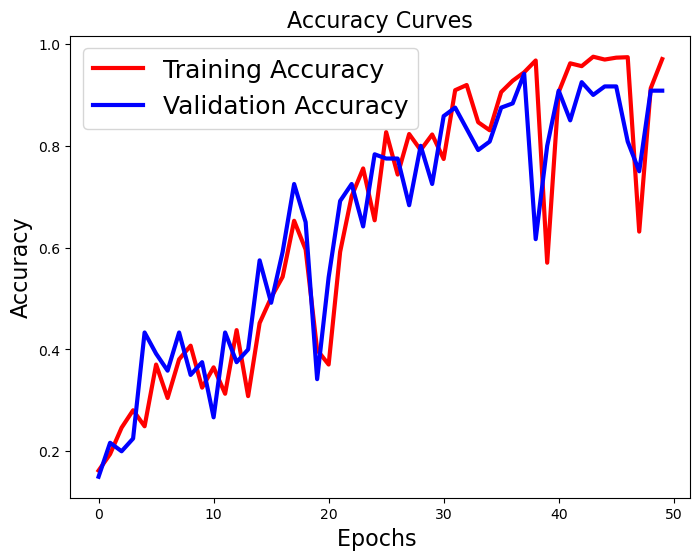

In [ ]:
model4.compile(optimizer='rmsprop', loss='categorical_crossentropy', metrics=['accuracy'])
history = model4.fit(train_data, Y_train_one_hot, batch_size=batch_size, epochs=epochs, verbose=1, 
                            validation_data=(test_data, Y_test_one_hot))

#Plot the Loss Curves
plt.figure(figsize=[8,6])
plt.plot(history.history['loss'],'r',linewidth=3.0)
plt.plot(history.history['val_loss'],'b',linewidth=3.0)
plt.legend(['Training loss', 'Validation Loss'],fontsize=18)
plt.xlabel('Epochs ',fontsize=16)
plt.ylabel('Loss',fontsize=16)
plt.title('Loss Curves',fontsize=16)

#Plot the Accuracy Curves
plt.figure(figsize=[8,6])
plt.plot(history.history['accuracy'],'r',linewidth=3.0)
plt.plot(history.history['val_accuracy'],'b',linewidth=3.0)
plt.legend(['Training Accuracy', 'Validation Accuracy'],fontsize=18)
plt.xlabel('Epochs ',fontsize=16)
plt.ylabel('Accuracy',fontsize=16)
plt.title('Accuracy Curves',fontsize=16)

In [316]:
[test_loss, test_acc] = model4.evaluate(test_data, Y_test_one_hot)
print("Evaluation result on Test Data : Loss = {}, accuracy = {}".format(test_loss, test_acc))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9083 - loss: 0.3115
Evaluation result on Test Data : Loss = 0.31146568059921265, accuracy = 0.9083333611488342


### Result

Output predict with best training model 
- - model4 with 6 hidden layer Conv2D and 1 Dense layer.
  and output layer, model with dropout(0.2) 

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


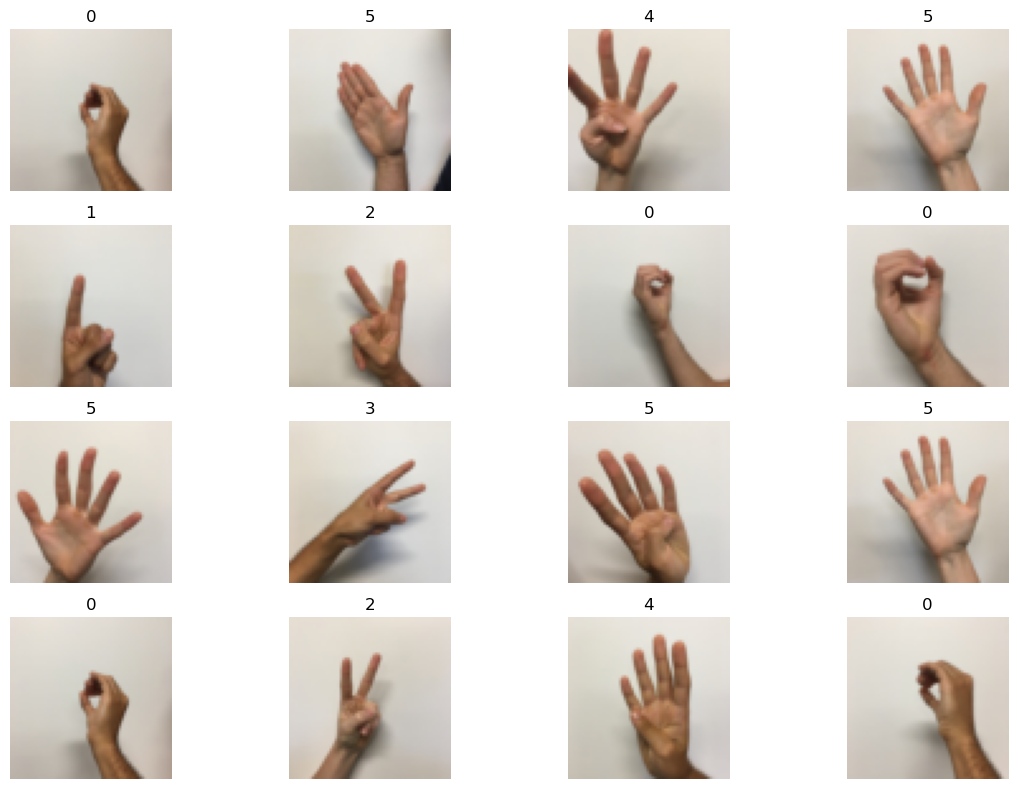

In [340]:
predicted = model4.predict(test_data)
predicted_classes = np.argmax(predicted, axis=1)

plt.figure(figsize= (12,8))
display_samples_in_grid(test_data, n_rows=4, n_cols=4, y= predicted_classes)
plt.tight_layout(h_pad=1, w_pad=1)